In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (update the path if your file name is different)
# '..' means go back one folder
df = pd.read_csv('../data/raw/creditcard.csv')

# Look at the first 5 rows
print(df.head())

# Check the distribution of Normal vs Fraudulent transactions
print(df['Class'].value_counts())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [7]:
from sklearn.preprocessing import StandardScaler

# We use StandardScaler to make 'Amount' have a mean of 0 and variance of 1
scaler = StandardScaler()

# Reshape is needed because scaler expects a 2D array
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

# Now we drop the original 'Amount' and the 'Time' column 
# (Time is usually not helpful for basic anomaly detection)
df_cleaned = df.drop(['Time', 'Amount'], axis=1)

print(df_cleaned.head())

         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V21       V22       V23       V24  \
0  0.098698  0.363787  0.090794  ... -0.018307  0.277838 -0.110474  0.066928   
1  0.085102 -0.255425 -0.166974  ... -0.225775 -0.638672  0.101288 -0.339846   
2  0.247676 -1.514654  0.207643  ...  0.247998  0.771679  0.909412 -0.689281   
3  0.377436 -1.387024 -0.054952  ... -0.108300  0.005274 -0.190321 -1.175575   
4 -0.270533  0.817739  0.753074  ... -0.009431  0.798278 -0.137458  0.141267   

        V25       V26       V27       V28  Class  scaled_amount  
0 

In [8]:
# Separate the features (X) from the target label (y)
X = df_cleaned.drop('Class', axis=1)
y = df_cleaned['Class']

print(f"Feature shape: {X.shape}")

Feature shape: (284807, 29)


In [9]:
from sklearn.ensemble import IsolationForest

# Define the model
# 'contamination' is the expected percentage of outliers (we know it's about 0.0017)
iso_forest = IsolationForest(n_estimators=100, 
                             contamination=0.0017, 
                             random_state=42)

# Fit the model
print("Training model... please wait.")
iso_forest.fit(X)

# Predict
# Isolation Forest returns -1 for anomalies and 1 for normal transactions
predictions = iso_forest.predict(X)

# Convert predictions to match our 'Class' column (0 for normal, 1 for fraud)
predictions[predictions == 1] = 0
predictions[predictions == -1] = 1

Training model... please wait.


--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.29      0.28      0.28       492

    accuracy                           1.00    284807
   macro avg       0.64      0.64      0.64    284807
weighted avg       1.00      1.00      1.00    284807



<Figure size 800x600 with 0 Axes>

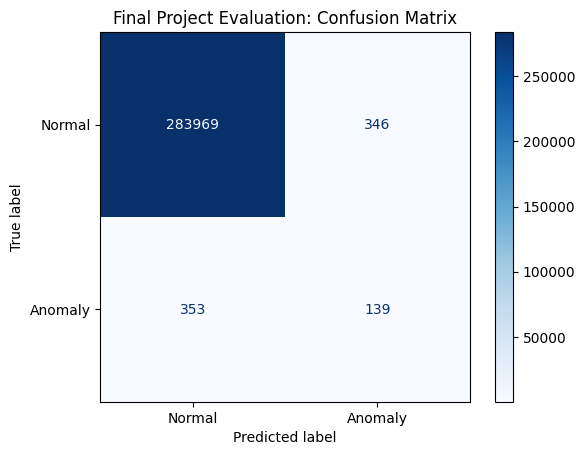

Total Frauds in Dataset: 492
Frauds Successfully Caught: 139
False Alarms: 346


In [10]:
# STEP 4: EVALUATION CODE

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Print the text-based results
print("--- Classification Report ---")
print(classification_report(y, predictions))

# 2. Create the Confusion Matrix
cm = confusion_matrix(y, predictions)

# 3. Plot the Visual Results
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Final Project Evaluation: Confusion Matrix')
plt.show()

# 4. Summary Statistics
total_fraud = (y == 1).sum()
caught_fraud = cm[1, 1]
false_alarms = cm[0, 1]

print(f"Total Frauds in Dataset: {total_fraud}")
print(f"Frauds Successfully Caught: {caught_fraud}")
print(f"False Alarms: {false_alarms}")

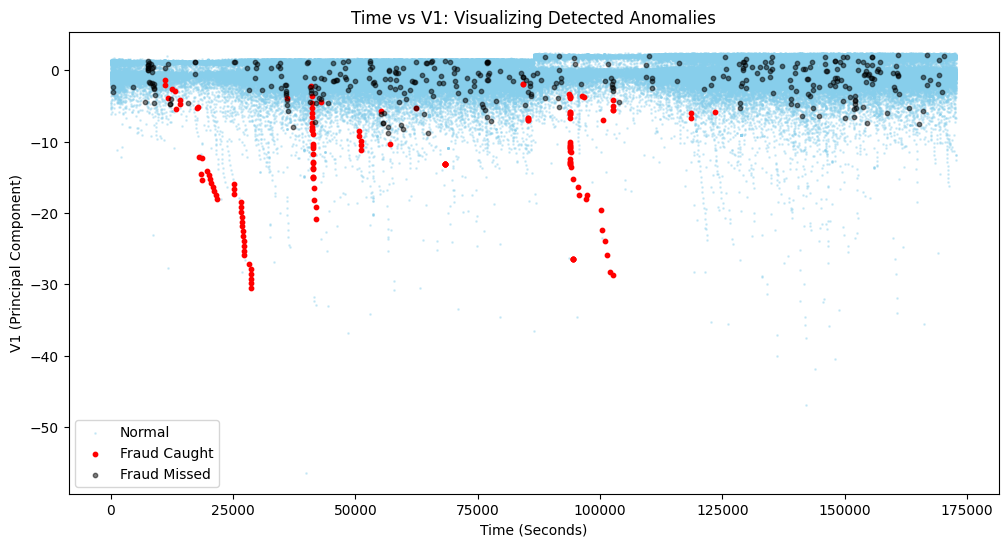

In [11]:
import matplotlib.pyplot as plt

# Create a temporary dataframe for plotting
plot_df = X.copy()
plot_df['Actual_Class'] = y
plot_df['Predicted_Anomaly'] = predictions
plot_df['Time'] = df['Time']

# Plot Normal vs Caught Fraud vs Missed Fraud
plt.figure(figsize=(12, 6))
plt.scatter(plot_df[plot_df['Actual_Class'] == 0]['Time'], plot_df[plot_df['Actual_Class'] == 0]['V1'], color='skyblue', label='Normal', alpha=0.3, s=1)
plt.scatter(plot_df[(plot_df['Actual_Class'] == 1) & (plot_df['Predicted_Anomaly'] == 1)]['Time'], plot_df[(plot_df['Actual_Class'] == 1) & (plot_df['Predicted_Anomaly'] == 1)]['V1'], color='red', label='Fraud Caught', s=10)
plt.scatter(plot_df[(plot_df['Actual_Class'] == 1) & (plot_df['Predicted_Anomaly'] == 0)]['Time'], plot_df[(plot_df['Actual_Class'] == 1) & (plot_df['Predicted_Anomaly'] == 0)]['V1'], color='black', label='Fraud Missed', s=10, alpha=0.5)

plt.title('Time vs V1: Visualizing Detected Anomalies')
plt.xlabel('Time (Seconds)')
plt.ylabel('V1 (Principal Component)')
plt.legend()
plt.show()

In [13]:
# TUNING THE MODEL
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix

# 1. Increase contamination to 0.005
tuned_model = IsolationForest(n_estimators=100,contamination=0.005,random_state=42)

# 2. Re-fit and Predict
print("Tuning model... please wait.")
tuned_model.fit(X)
tuned_predictions = tuned_model.predict(X)

# 3. Convert predictions (1 -> 0, -1 -> 1)
tuned_predictions[tuned_predictions == 1] = 0
tuned_predictions[tuned_predictions == -1] = 1

# 4. Check the new results
new_cm = confusion_matrix(y, tuned_predictions)
new_caught = new_cm[1, 1]
new_false_alarms = new_cm[0, 1]

print(f"--- TUNED RESULTS ---")
print(f"Frauds Caught: {new_caught} (Previously 139)")
print(f"False Alarms: {new_false_alarms} (Previously 346)")

Tuning model... please wait.
--- TUNED RESULTS ---
Frauds Caught: 229 (Previously 139)
False Alarms: 1195 (Previously 346)


In [14]:
# STEP 6: FEATURE IMPORTANCE (EXPLAINABILITY)
import pandas as pd

# Get the anomaly scores (lower scores = more anomalous)
scores = tuned_model.decision_function(X)

# Add scores to our dataframe
X_results = X.copy()
X_results['anomaly_score'] = scores
X_results['is_fraud'] = y

# Look at the top 5 'weirdest' transactions we caught
top_anomalies = X_results[X_results['is_fraud'] == 1].sort_values(by='anomaly_score').head(5)

print("--- Top 5 Most Anomalous Frauds ---")
print(top_anomalies[['scaled_amount', 'anomaly_score']])

--- Top 5 Most Anomalous Frauds ---
        scaled_amount  anomaly_score
154371      -0.344114      -0.140524
154587      -0.353229      -0.139125
154684      -0.353189      -0.136024
154234      -0.349231      -0.135691
153823      -0.344114      -0.135583
